# 02 – Feature Engineering & Modelle

Ziel des Notebooks
- Aufbereitung der Features (Feature Engineering und Preprocessing)
- Entwicklung von Modellen 
    - Erstellung einer ML-Pipeline
    - Trainieren verschiedener Modelle
    - Evalulierung erster Metriken (MAE, RMSE und R²)
- Analyse der Features Importances


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib
import os

In [2]:
# Daten laden

df = pd.read_csv("../data/processed/sample_listings.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price                 5000 non-null   float64
 1   neighbourhood         5000 non-null   object 
 2   room_type             5000 non-null   object 
 3   minimum_nights        5000 non-null   int64  
 4   number_of_reviews     5000 non-null   int64  
 5   review_scores_rating  5000 non-null   float64
 6   amenities             5000 non-null   object 
 7   latitude              5000 non-null   float64
 8   longitude             5000 non-null   float64
dtypes: float64(4), int64(2), object(3)
memory usage: 351.7+ KB


In [3]:
# Feature Engineering

df_model = df.copy()

# Generiere eines neuen Features (Anzahl der Ausstattungsmerkmale)
# Hypothese: Anzahl der Ausstattungsmerkmale (amenities) beeinflusst den Preis

def count_amenities(amenities):
    """
    Zählen der Ausstattungsmerkmale, die als String 
    im Format "{Ausstattung1, Ausstattung2, ...}" vorliegen.
    Beispiel: "{Wifi, Kitchen, Heating}" -> 3
    Rückgabe: 0, wenn der String leer oder NaN ist.
    """
    if pd.isna(amenities):
        return 0

    cleaned = str(amenities).strip("{}").strip()
    if not cleaned:
        return 0

    return sum(1 for a in cleaned.split(",") if a.strip())

df_model["amenity_count"] = df_model["amenities"].apply(count_amenities)
df_model = df_model.drop(columns=["amenities"])


df_model.head()


,price,neighbourhood,room_type,minimum_nights,number_of_reviews,review_scores_rating,latitude,longitude,amenity_count
0,205.0,I Centro Storico,Entire home/apt,1,59,4.68,41.877946,12.473666,53
1,149.0,VIII Appia Antica,Entire home/apt,3,13,5.00,41.860463,12.483244,50
2,67.0,XIII Aurelia,Entire home/apt,1,94,4.95,41.894668,12.447176,32
3,102.0,I Centro Storico,Private room,5,435,4.80,41.894140,12.506500,18
4,140.0,I Centro Storico,Entire home/apt,2,54,4.76,41.912990,12.455640,37


In [4]:
# Spalten in kategorische und numerische Features aufteilen

numeric_features = [
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "latitude",
    "longitude",
    "amenity_count",
]

categorical_features = [
    "neighbourhood",
    "room_type",
]

print("Numerische Features:", numeric_features)
print("Kategorische Features:", categorical_features)


Numerische Features: ['minimum_nights', 'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude', 'amenity_count']
Kategorische Features: ['neighbourhood', 'room_type']


In [5]:
# Preprocessing-Pipeline für numerische und kategoriale Features erstellen

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),  
])


In [6]:
# Trainings- und Testset definieren

# Zielvariable definieren
target_col = "price"

# Features X und Zielvariable y definieren
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.head()


,neighbourhood,room_type,minimum_nights,number_of_reviews,review_scores_rating,latitude,longitude,amenity_count
4227,I Centro Storico,Private room,3,116,4.92,41.896200,12.494670,35
4676,I Centro Storico,Private room,1,1,5.00,41.920690,12.459690,23
800,XII Monte Verde,Entire home/apt,2,180,4.80,41.874520,12.445410,37
3671,I Centro Storico,Entire home/apt,2,65,4.80,41.889100,12.467871,33
4193,I Centro Storico,Entire home/apt,3,25,4.76,41.889951,12.466232,18


In [7]:
# ML- Pipeline mit RandomForestRegressor

# Modell initialisieren
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print(f"Modell initialisiert: RandomForestRegressor mit {rf.n_estimators} Bäumen.")

# RandomForest-Pipeline erstellen
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf)
    ]
)

# Modell trainieren
rf_pipeline.fit(X_train, y_train)

print("Random Forest trainiert.")

# Vorhersagen treffen
y_pred = rf_pipeline.predict(X_test)

# Erste Modell-Evaluierung
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Erste Modell-Evaluierung:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.3f}")

# Tatsächliche und vorhergesagte Preise speichern
os.makedirs("../models", exist_ok=True)

pred_df_rf = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
})

pred_df_rf.to_csv("../models/predictions_rf.csv", index=False)

print("Vorhersagen gespeichert unter '../models/predictions_rf.csv'.")

# Modell speichern
joblib.dump(rf_pipeline, "../models/rf_pipeline.pkl")
print("Modell gespeichert unter '../models/rf_pipeline.pkl'.")

Modell initialisiert: RandomForestRegressor mit 200 Bäumen.
Random Forest trainiert.
Erste Modell-Evaluierung:
RMSE: 68.20
MAE:  47.26
R²:   0.349
Vorhersagen gespeichert unter '../models/predictions_rf.csv'.
Modell gespeichert unter '../models/rf_pipeline.pkl'.


In [8]:
# ML- Pipeline mit RandomForestRegressor (mit log-transformierter Zielvariable)

# Zielvariable log-transformieren
y_train_log = np.log1p(y_train)     # log(1 + y)

print("Zielvariable log1p-transformiert.")

# Modell initialisieren
rf_log = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print(f"Modell initialisiert: RandomForestRegressor mit log-y und {rf_log.n_estimators} Bäumen.")

# RandomForest-Pipeline erstellen
rf_log_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf_log)
    ]
)

# Modell auf log-transformierter Zielvariable trainieren
rf_log_pipeline.fit(X_train, y_train_log)

print("Random Forest mit log-y trainiert.")

# Vorhersagen im log-Raum treffen
y_pred_rf_log = rf_log_pipeline.predict(X_test)

# Vorhersagen zurück-transformieren
y_pred = np.expm1(y_pred_rf_log)  # wieder in €
y_true = y_test

# Erste Modell-Evaluierung
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Erste Modell-Evaluierung:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.3f}")

# Tatsächliche und vorhergesagte Preise speichern
os.makedirs("../models", exist_ok=True)

pred_df_rf_log = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred
})

pred_df_rf_log["y_true"] = pred_df_rf_log["y_true"].round(2)
pred_df_rf_log["y_pred"] = pred_df_rf_log["y_pred"].round(2)

pred_df_rf_log.to_csv("../models/predictions_rf_log.csv", index=False)

print("Vorhersagen gespeichert unter '../models/predictions_rf_log.csv'.")

# Modell speichern
joblib.dump(rf_log_pipeline, "../models/rf_log_pipeline.pkl")
print("Modell gespeichert unter '../models/rf_log_pipeline.pkl'.")

Zielvariable log1p-transformiert.
Modell initialisiert: RandomForestRegressor mit log-y und 200 Bäumen.
Random Forest mit log-y trainiert.
Erste Modell-Evaluierung:
RMSE: 68.30
MAE:  45.33
R²:   0.347
Vorhersagen gespeichert unter '../models/predictions_rf_log.csv'.
Modell gespeichert unter '../models/rf_log_pipeline.pkl'.


In [9]:
# ML- Pipeline mit RandomForestRegressor (mit log-transformierter Zielvariable)

# Zielvariable log-transformieren
y_train_log = np.log1p(y_train)     # log(1 + y)

print("Zielvariable log1p-transformiert.")

# Modell initialisieren
xgb_log = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print(f"Modell initialisiert: XGBRegressor mit log-y und {xgb_log.n_estimators} Bäumen.")

# XGB-Pipeline erstellen
xgb_log_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_log)
    ]
)

# Modell auf log-transformierter Zielvariable trainieren
xgb_log_pipeline.fit(X_train, y_train_log)

print("XGBoost mit log-y trainiert.")

# Vorhersagen im log-Raum treffen
y_pred_xgb_log = xgb_log_pipeline.predict(X_test)

# Vorhersagen zurück-transformieren
y_pred = np.expm1(y_pred_xgb_log)  # wieder in €
y_true = y_test

# Erste Modell-Evaluierung
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Erste Modell-Evaluierung:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.3f}")

# Tatsächliche und vorhergesagte Preise speichern
os.makedirs("../models", exist_ok=True)

pred_df_xgb_log = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred
})

pred_df_xgb_log["y_true"] = pred_df_xgb_log["y_true"].round(2)
pred_df_xgb_log["y_pred"] = pred_df_xgb_log["y_pred"].round(2)


pred_df_xgb_log.to_csv("../models/predictions_xgb_log.csv", index=False)

print("Vorhersagen gespeichert unter '../models/predictions_xgb_log.csv'.")
# Modell speichern
joblib.dump(xgb_log_pipeline, "../models/xgb_log_pipeline.pkl")
print("Modell gespeichert unter '../models/xgb_log_pipeline.pkl'.")

print(pred_df_xgb_log.head())

Zielvariable log1p-transformiert.
Modell initialisiert: XGBRegressor mit log-y und 300 Bäumen.
XGBoost mit log-y trainiert.
Erste Modell-Evaluierung:
RMSE: 68.08
MAE:  44.84
R²:   0.351
Vorhersagen gespeichert unter '../models/predictions_xgb_log.csv'.
Modell gespeichert unter '../models/xgb_log_pipeline.pkl'.
      y_true      y_pred
1501    73.0   98.330002
2586    83.0  105.330002
2653    81.0   77.139999
1055   107.0   80.800003
705    104.0  107.029999


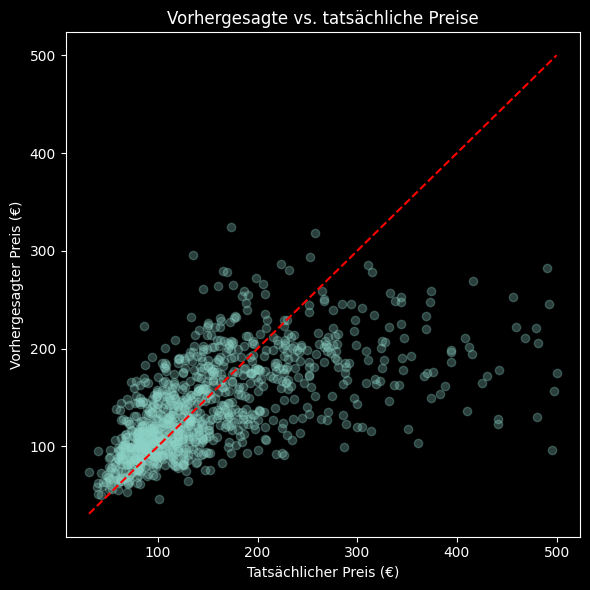

In [10]:
# Plot mit tatsächlichen vs. vorhergesagten Preisen

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("Vorhergesagte vs. tatsächliche Preise")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.tight_layout()
plt.show()


In [11]:
# Feature Importance extrahieren

# Modell extrahieren
rf = clf.named_steps["model"]

# Namen der OHE-Features extrahieren
ohe = clf.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

# Alle Feature-Namen zusammenfügen
feature_names = np.concatenate([numeric_features, ohe_feature_names])

# Feature Importances als DataFrame
importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importances.head(15)


NameError: name 'clf' is not defined

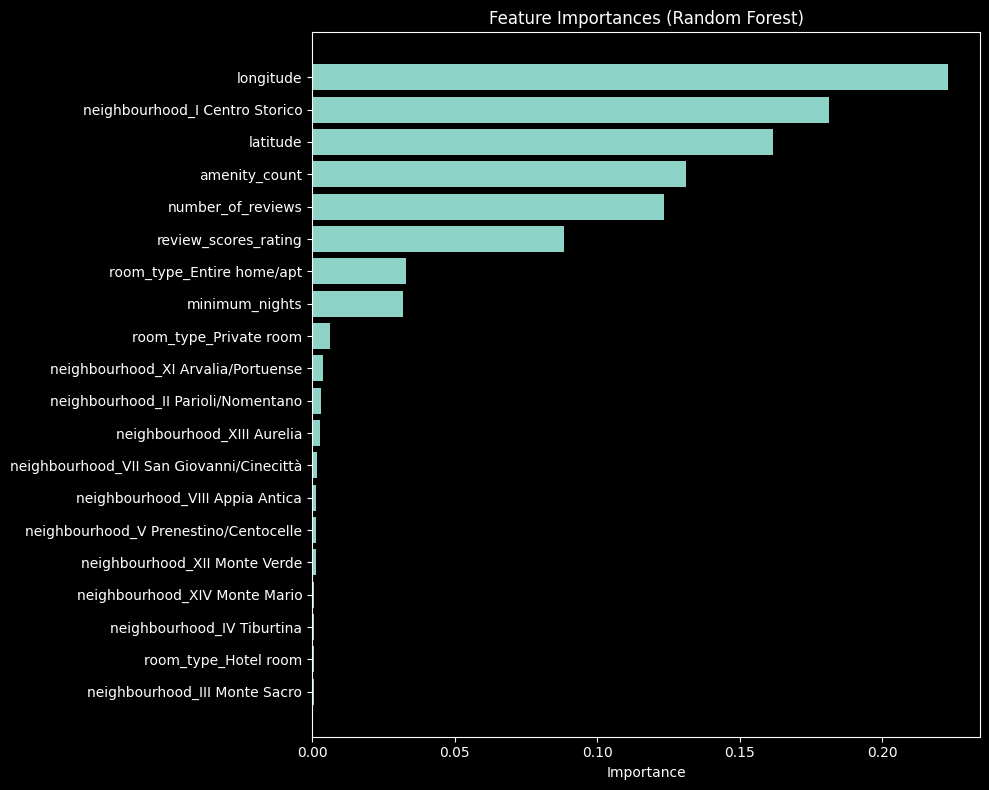

In [ ]:
# Feature Importances visualisieren

top_n = 20  # die 20 wichtigsten Features

plt.figure(figsize=(10, 8))
plt.barh(
    importances.head(top_n)["feature"][::-1],
    importances.head(top_n)["importance"][::-1],
)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## Fazit

- Einfaches Feature Engineering für `amenities` durchgeführt
-  Pipeline für das erstes Modell erstellt
    - Preprocessing mit One-Hot-Encoding für kategoriale Features (`neighbourhood` und `room_type`)
    - Trainieren eines RandomForestRegressor
- Erstes Modell liefert Metriken, die als Baseline verwendet werden können
- Wichtigkeit der bedeutendsten Features visualisiert
    - Lage (`longitude` und `latitude`) zentraler Preistreiber
    - `amenities_count` gehört zu den wichtigsten Features
- Erweiterung des Modells mit log-transfomierter Zielvariablen im nächsten Schritt, da vorteilhaft für RandomForestRegressor: 
    - bessere Splits 
    - weniger Einfluss extremer Werte
    - geringere Varianz zwischen den Bäumen